# Análisis Exploratorio - Dataset Automóviles
Dataset: Automobile.csv  


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Automobile.csv')

origin_map = {'usa': 'USA', 'europe': 'Europa', 'japan': 'Japón'}
df['origin_label'] = df['origin'].map(origin_map)

df.head()

,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,origin_label
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa,USA
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa,USA
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa,USA
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa,USA
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa,USA


---
## Gráfico 1 — Relación entre peso y consumo (mpg)

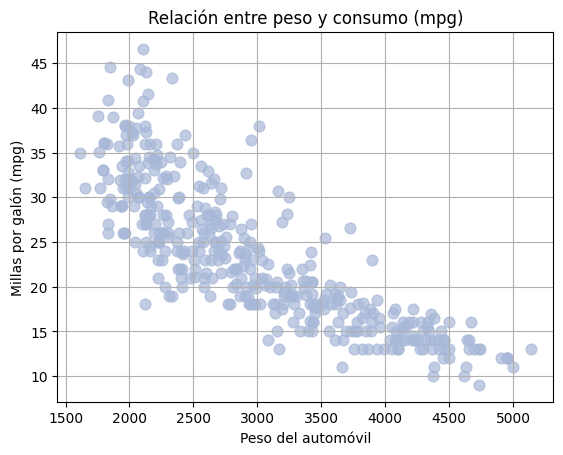

In [4]:
plt.scatter(df['weight'], df['mpg'], c='#a8b8d8', alpha=0.7, s=60)

plt.title('Relación entre peso y consumo (mpg)')
plt.xlabel('Peso del automóvil')
plt.ylabel('Millas por galón (mpg)')
plt.grid(True)

plt.savefig('01_scatter_mpg_vs_weight.png')
plt.show()

---
## Gráfico 2 — Distribución de mpg (histograma)

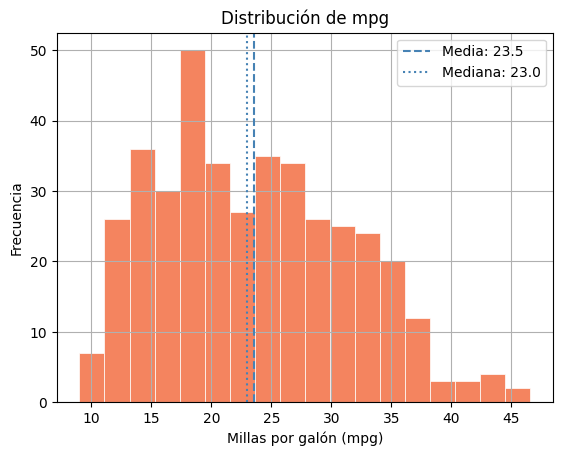

In [5]:
media   = df['mpg'].mean()
mediana = df['mpg'].median()

plt.hist(df['mpg'], bins=18, color='#f4845f', edgecolor='white', linewidth=0.5)

plt.axvline(media,   color='steelblue', linestyle='--', linewidth=1.5, label=f'Media: {media:.1f}')
plt.axvline(mediana, color='steelblue', linestyle=':',  linewidth=1.5, label=f'Mediana: {mediana:.1f}')

plt.title('Distribución de mpg')
plt.xlabel('Millas por galón (mpg)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)

plt.savefig('02_hist_mpg.png')
plt.show()

---
## Gráfico 3 — Distribución de mpg según cantidad de cilindros

C:\Users\corre\AppData\Local\Temp\ipykernel_16552\3280044489.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(datos_cil, labels=cilindros, patch_artist=True,


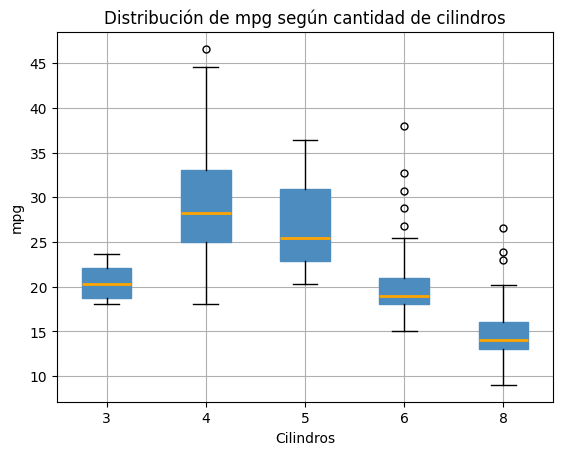

In [6]:
cilindros  = sorted(df['cylinders'].unique())
datos_cil  = [df[df['cylinders'] == c]['mpg'].values for c in cilindros]

plt.boxplot(datos_cil, labels=cilindros, patch_artist=True,
            boxprops=dict(facecolor='#4c8cbf', color='#4c8cbf'),
            medianprops=dict(color='orange', linewidth=2),
            flierprops=dict(marker='o', markerfacecolor='none', markersize=5))

plt.title('Distribución de mpg según cantidad de cilindros')
plt.xlabel('Cilindros')
plt.ylabel('mpg')
plt.grid(True)

plt.savefig('03_box_mpg_por_cylinders.png')
plt.show()

---
## Gráfico 4 — Distribución de mpg según origen

C:\Users\corre\AppData\Local\Temp\ipykernel_16552\922596301.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(datos_ori, labels=origenes, patch_artist=True,


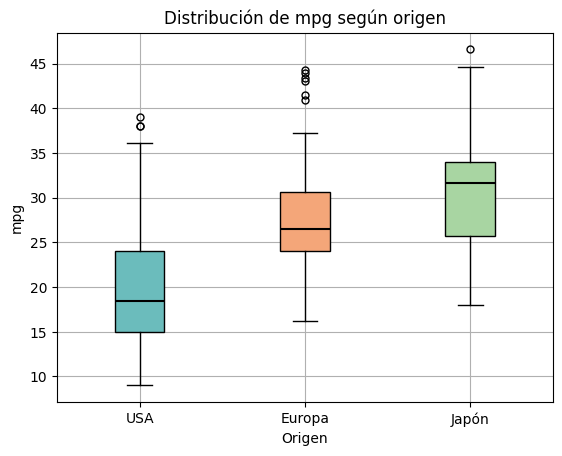

In [7]:
origenes  = ['USA', 'Europa', 'Japón']
colores   = ['#6bbcbc', '#f4a679', '#a8d5a2']
datos_ori = [df[df['origin_label'] == o]['mpg'].values for o in origenes]

bp = plt.boxplot(datos_ori, labels=origenes, patch_artist=True,
                 medianprops=dict(color='black', linewidth=1.5),
                 flierprops=dict(marker='o', markerfacecolor='none', markersize=5))

for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)

plt.title('Distribución de mpg según origen')
plt.xlabel('Origen')
plt.ylabel('mpg')
plt.grid(True)

plt.savefig('04_box_mpg_por_origin.png')
plt.show()

---
## Gráfico 5 — Distribución de automóviles por año y origen

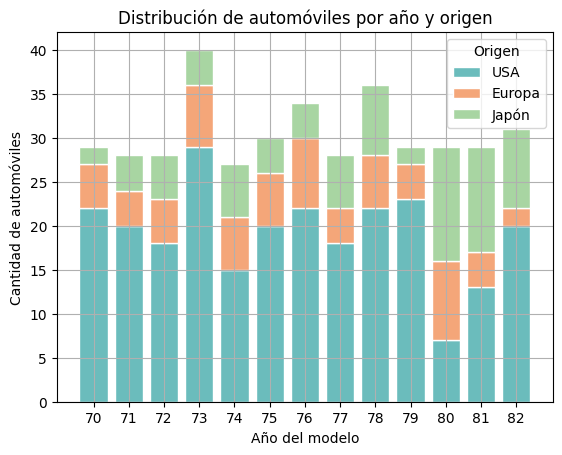

In [8]:
pivot = (
    df.groupby(['model_year', 'origin_label'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['USA', 'Europa', 'Japón'])
)

years   = pivot.index
x       = range(len(years))
colores = ['#6bbcbc', '#f4a679', '#a8d5a2']

bottom = [0] * len(years)
for col, color in zip(['USA', 'Europa', 'Japón'], colores):
    valores = pivot[col].values
    plt.bar(x, valores, bottom=bottom, color=color, label=col, edgecolor='white')
    bottom = [b + v for b, v in zip(bottom, valores)]

plt.title('Distribución de automóviles por año y origen')
plt.xlabel('Año del modelo')
plt.ylabel('Cantidad de automóviles')
plt.xticks(x, years)
plt.legend(title='Origen')
plt.grid(True)

plt.savefig('05_barras_modelyear_origin.png')
plt.show()